<a href="https://colab.research.google.com/github/TejasKayarkar03/Pattern-Recognition-Lab/blob/main/PR_CM23045_PostLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install necessary libraries if missing
!pip install scikit-learn matplotlib seaborn numpy pandas --quiet

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

print("Setup completed successfully!")

Setup completed successfully!


In [2]:
class SyntacticPlateValidator:
    def __init__(self):
        # Production Rule Syntax:
        # <Plate> ::= <StateCode>[2] <Separator>? <DistrictCode>[2] <Separator>? <Series>[1-3] <Separator>? <Number>[4]
        self.pattern = re.compile(r'^[A-Z]{2}[-\s]?\d{2}[-\s]?[A-Z]{1,3}[-\s]?\d{4}$')

    def validate(self, plate_string):
        cleaned_plate = plate_string.strip().upper()
        is_valid = bool(self.pattern.match(cleaned_plate))
        return cleaned_plate, is_valid

# Test Phase 1
validator = SyntacticPlateValidator()
test_plates = ["MH-12-AB-1234", "DL01C9999", "KA-05-12345", "INVALID_123", "NY-88-Z-0001"]

print("--- PHASE 1: Syntactic Number Plate Validation Results ---")
for plate in test_plates:
    fmt_plate, valid = validator.validate(plate)
    status = "VALID PASS" if valid else "REJECTED (Invalid Syntax)"
    print(f"Plate: {fmt_plate:<15} -> {status}")

--- PHASE 1: Syntactic Number Plate Validation Results ---
Plate: MH-12-AB-1234   -> VALID PASS
Plate: DL01C9999       -> VALID PASS
Plate: KA-05-12345     -> REJECTED (Invalid Syntax)
Plate: INVALID_123     -> REJECTED (Invalid Syntax)
Plate: NY-88-Z-0001    -> VALID PASS


--- PHASE 2: Handwritten Digit Recognition Results ---
Handwritten Digit Classification Accuracy: 98.89%



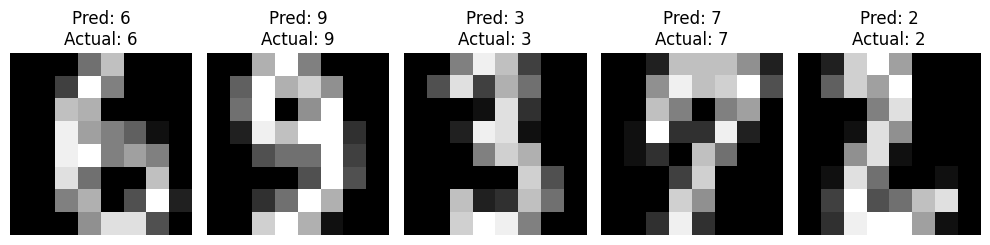

In [3]:
from sklearn.neighbors import KNeighborsClassifier

# Load handwritten digits dataset
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

# Split dataset
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=42
)

# Train a KNN classifier for pattern matching
digit_classifier = KNeighborsClassifier(n_neighbors=3)
digit_classifier.fit(X_train_d, y_train_d)

# Evaluate model
y_pred_d = digit_classifier.predict(X_test_d)
acc_d = accuracy_score(y_test_d, y_pred_d)

print("--- PHASE 2: Handwritten Digit Recognition Results ---")
print(f"Handwritten Digit Classification Accuracy: {acc_d * 100:.2f}%\n")

# Visualize sample test predictions
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test_d[i].reshape(8, 8), cmap='gray')
    ax.set_title(f"Pred: {y_pred_d[i]}\nActual: {y_test_d[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

--- PHASE 3: Decision Tree Authorization Engine ---
Decision Tree Accuracy: 100.00%

              precision    recall  f1-score   support

      Denied       1.00      1.00      1.00        43
    Approved       1.00      1.00      1.00        32

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



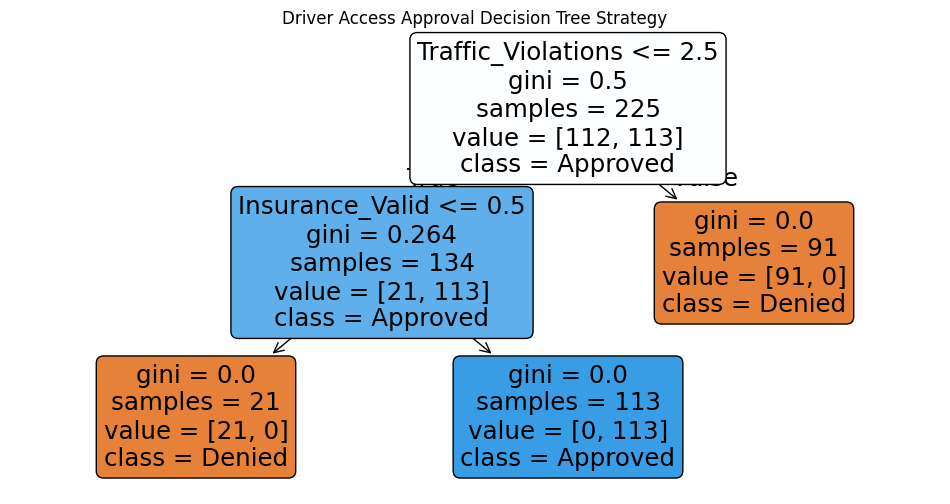

In [4]:
# Generate synthetic driver profile data
np.random.seed(42)
n_samples = 300

data = {
    'Age': np.random.randint(18, 70, size=n_samples),
    'Traffic_Violations': np.random.randint(0, 5, size=n_samples),
    'Has_Toll_Pass': np.random.choice([0, 1], size=n_samples),
    'Insurance_Valid': np.random.choice([0, 1], size=n_samples, p=[0.2, 0.8])
}

df = pd.DataFrame(data)

# Target Rule: Approved (1) if no major violations and valid insurance
df['Approved'] = np.where(
    (df['Insurance_Valid'] == 1) & (df['Traffic_Violations'] <= 2), 1, 0
)

# Features & Target
X_driver = df[['Age', 'Traffic_Violations', 'Has_Toll_Pass', 'Insurance_Valid']]
y_driver = df['Approved']

# Train-Test Split
X_train_drv, X_test_drv, y_train_drv, y_test_drv = train_test_split(
    X_driver, y_driver, test_size=0.25, random_state=42
)

# Train Decision Tree
tree_clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
tree_clf.fit(X_train_drv, y_train_drv)

# Predictions & Performance
y_pred_drv = tree_clf.predict(X_test_drv)
acc_tree = accuracy_score(y_test_drv, y_pred_drv)

print("--- PHASE 3: Decision Tree Authorization Engine ---")
print(f"Decision Tree Accuracy: {acc_tree * 100:.2f}%\n")
print(classification_report(y_test_drv, y_pred_drv, target_names=['Denied', 'Approved']))

# Plot the Decision Tree structure
plt.figure(figsize=(12, 6))
plot_tree(
    tree_clf,
    feature_names=X_driver.columns.tolist(),
    class_names=['Denied', 'Approved'],
    filled=True,
    rounded=True
)
plt.title("Driver Access Approval Decision Tree Strategy")
plt.show()

In [6]:
# Step 1: Install EasyOCR and visualization utilities
!pip install easyocr opencv-python matplotlib pandas --quiet

import cv2
import easyocr
import re
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Initialize the EasyOCR reader (English recognition)
reader = easyocr.Reader(['en'], gpu=True)
print("EasyOCR Reader initialized successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 9.1 MB/s eta 0:00:00


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR Reader initialized successfully!


In [7]:
class LicensePlateDetector:
    def __init__(self):
        # Formal grammar pattern for license plate syntax (e.g., MH-12-AB-1234 or MH12AB1234)
        self.plate_pattern = re.compile(r'^[A-Z]{2}[-\s]?\d{2}[-\s]?[A-Z]{1,3}[-\s]?\d{4}$')

    def preprocess_image(self, image_path):
        """Load and prepare image for OCR."""
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image, image_rgb

    def extract_plate_text(self, image_path):
        """Detect text bounding boxes and extract license plate string using EasyOCR."""
        results = reader.readtext(image_path)

        extracted_texts = []
        bounding_boxes = []

        for (bbox, text, prob) in results:
            # Clean OCR string output
            cleaned_text = re.sub(r'[^A-Z0-9]', '', text.upper())
            if len(cleaned_text) >= 6:  # Filter noise/short words
                extracted_texts.append((cleaned_text, prob))
                bounding_boxes.append(bbox)

        return extracted_texts, bounding_boxes

    def validate_syntax(self, plate_str):
        """Check if extracted plate matches formal Context-Free Grammar syntax rules."""
        is_valid = bool(self.plate_pattern.match(plate_str))
        return is_valid

# Initialize Detector
detector = LicensePlateDetector()

Saving images (6).jpeg to images (6).jpeg

Processing File: images (6).jpeg


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


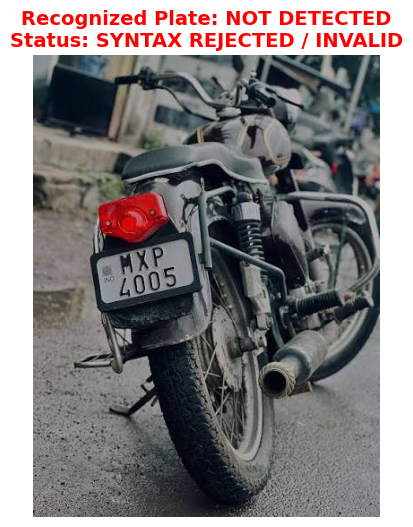

RAW OCR TEXT DETECTED     : NOT DETECTED
N/A
SYNTACTIC GRAMMAR CHECK   : FAILED ❌


In [13]:
# Upload Image File
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nProcessing File: {filename}")

    # 1. Preprocess & Read Image
    original_bgr, display_rgb = detector.preprocess_image(filename)

    # 2. Extract OCR Text & Bounding Boxes
    detections, boxes = detector.extract_plate_text(filename)

    # Visual Overlay Preparation
    annotated_img = display_rgb.copy()
    recognized_plate = "NOT DETECTED"
    is_valid_plate = False

    # 3. Process Best Match Detection
    if detections:
        # Sort detections by probability score
        best_detection = max(detections, key=lambda x: x[1])
        recognized_plate = best_detection[0]
        confidence = best_detection[1]

        # Syntactic Pattern Validation
        is_valid_plate = detector.validate_syntax(recognized_plate)

        # Draw Bounding Box around detected plate
        best_idx = detections.index(best_detection)
        pts = np.array(boxes[best_idx], dtype=np.int32)
        cv2.polylines(annotated_img, [pts], True, (0, 255, 0) if is_valid_plate else (255, 0, 0), 4)

    # 4. Display Processing Results
    plt.figure(figsize=(10, 6))
    plt.imshow(annotated_img)
    plt.axis('off')

    status_color = "GREEN" if is_valid_plate else "RED"
    status_text = "VALID SYNTAX PASS" if is_valid_plate else "SYNTAX REJECTED / INVALID"

    plt.title(f"Recognized Plate: {recognized_plate}\nStatus: {status_text}",
              fontsize=14, color='green' if is_valid_plate else 'red', fontweight='bold')
    plt.show()

    # Console Summary Log
    print("=" * 50)
    print(f"RAW OCR TEXT DETECTED     : {recognized_plate}")
    print(f"OCR CONFIDENCE SCORE      : {confidence * 100:.2f}%" if detections else "N/A")
    print(f"SYNTACTIC GRAMMAR CHECK   : {'SUCCESS ✓' if is_valid_plate else 'FAILED ❌'}")
    print("=" * 50)

Saving speedex-number-plates-and-speciality-coatings-nandanam-chennai-car-number-plate-manufacturers-ocru7o8q2i.avif to speedex-number-plates-and-speciality-coatings-nandanam-chennai-car-number-plate-manufacturers-ocru7o8q2i.avif

Processing File: speedex-number-plates-and-speciality-coatings-nandanam-chennai-car-number-plate-manufacturers-ocru7o8q2i.avif


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


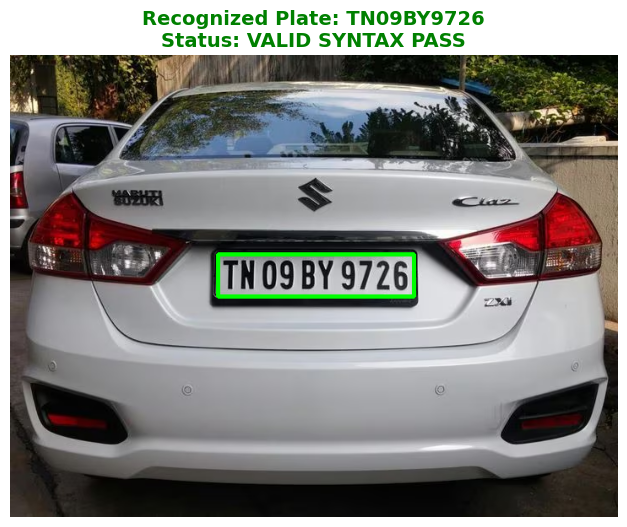

RAW OCR TEXT DETECTED     : TN09BY9726
OCR CONFIDENCE SCORE      : 80.99%
SYNTACTIC GRAMMAR CHECK   : SUCCESS ✓


In [11]:
# Upload Image File
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nProcessing File: {filename}")

    # 1. Preprocess & Read Image
    original_bgr, display_rgb = detector.preprocess_image(filename)

    # 2. Extract OCR Text & Bounding Boxes
    detections, boxes = detector.extract_plate_text(filename)

    # Visual Overlay Preparation
    annotated_img = display_rgb.copy()
    recognized_plate = "NOT DETECTED"
    is_valid_plate = False

    # 3. Process Best Match Detection
    if detections:
        # Sort detections by probability score
        best_detection = max(detections, key=lambda x: x[1])
        recognized_plate = best_detection[0]
        confidence = best_detection[1]

        # Syntactic Pattern Validation
        is_valid_plate = detector.validate_syntax(recognized_plate)

        # Draw Bounding Box around detected plate
        best_idx = detections.index(best_detection)
        pts = np.array(boxes[best_idx], dtype=np.int32)
        cv2.polylines(annotated_img, [pts], True, (0, 255, 0) if is_valid_plate else (255, 0, 0), 4)

    # 4. Display Processing Results
    plt.figure(figsize=(10, 6))
    plt.imshow(annotated_img)
    plt.axis('off')

    status_color = "GREEN" if is_valid_plate else "RED"
    status_text = "VALID SYNTAX PASS" if is_valid_plate else "SYNTAX REJECTED / INVALID"

    plt.title(f"Recognized Plate: {recognized_plate}\nStatus: {status_text}",
              fontsize=14, color='green' if is_valid_plate else 'red', fontweight='bold')
    plt.show()

    # Console Summary Log
    print("=" * 50)
    print(f"RAW OCR TEXT DETECTED     : {recognized_plate}")
    print(f"OCR CONFIDENCE SCORE      : {confidence * 100:.2f}%" if detections else "N/A")
    print(f"SYNTACTIC GRAMMAR CHECK   : {'SUCCESS ✓' if is_valid_plate else 'FAILED ❌'}")
    print("=" * 50)